In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
!pip install pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.6/22.6 MB 23.6 MB/s eta 0:00:0000:0100:01


In [4]:
df = pd.read_feather('merfish.feather')

In [5]:
test = df

In [6]:
test['Npyr'] = test.Npy1r + test.Npy2r
print(test[test.Npyr>1].shape[0]/test.shape[0])

0.6295600127645333


In [26]:
test_hr = test[ (test.Esr1 >0) & (test.Pgr >0) & (test.Cell_class.isin(['Inhibitory']))]
# test_hr = test
test_hr = test_hr.iloc[:, 9:].drop(columns = ['Fos']).dropna()
test_hr['Pgr_esr'] = np.log(test_hr.Pgr / test_hr.Esr1)
test_hr['Npyr'] = test_hr.Npy1r + test_hr.Npy2r
test_hr = test_hr[test_hr.Npyr>0]
test_hr['Gabra1_log'] = np.log(test_hr['Gabra1'])

/Users/caom/Documents/switch_imaging/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


/Users/caom/Documents/switch_imaging/.venv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


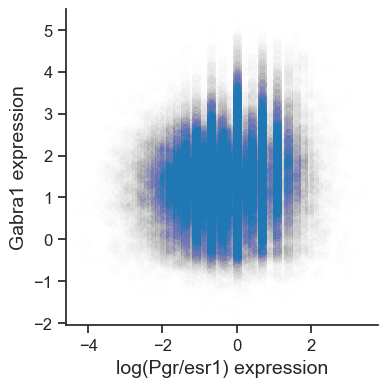

In [27]:
plt.rcParams['figure.figsize'] = 7,5
sns.set_theme(style="ticks")
sns.lmplot(x = 'Pgr_esr', y = 'Gabra1_log' , data = test_hr,scatter_kws={'alpha':0.002, 'color': 'Tab:blue'}, line_kws={'color': 'Tab:blue'},  height=4, aspect=1)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xlabel('log(Pgr/esr1) expression', fontsize = 14)
plt.ylabel('Gabra1 expression', fontsize = 14)      
plt.savefig('output_figures/Gabra1_corr.png',dpi = 300, bbox_inches = 'tight')
plt.show()

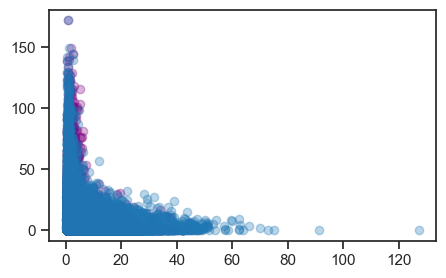

In [28]:
plt.subplots(figsize = (5,3))
plt.scatter(test_hr.Pgr, test_hr.Gabra1 , color = 'purple', alpha = 0.3)
plt.scatter(test_hr.Esr1, test_hr.Gabra1, color = 'Tab:blue', alpha = 0.3)
plt.show()

In [29]:
corr =test_hr.corr().Pgr_esr
display(corr.sort_values())


Esr1         -0.560033
Coch         -0.164719
Scg2         -0.156052
Ar           -0.153568
Ntng1        -0.133731
                ...   
Syt2          0.086817
Gabra1_log    0.114396
Gabra1        0.122658
Pgr           0.264186
Pgr_esr       1.000000
Name: Pgr_esr, Length: 163, dtype: float64

In [49]:
corr =test_hr.corr().Esr1
corr.sort_values()

Pgr_esr   -0.560033
Gabra1    -0.179996
Ccnd2     -0.121547
Synpr     -0.107370
Isl1      -0.104031
             ...   
Coch       0.308312
Scg2       0.345111
Ntng1      0.351045
Pgr        0.446096
Esr1       1.000000
Name: Esr1, Length: 162, dtype: float64